In [17]:
import requests
import json
import math

API_KEY = "33dfc12d7b4989174ea89bfa71c23540"

#调用高德POI的搜索接口
def search_poi(keywords,city,page=1,offset=25):
    url = "https://restapi.amap.com/v3/place/text"
    params = {
        "key":API_KEY,
        "keywords":keywords,
        "city":city,
        "citylimit":"true",
        "output":"json",
        "offset":offset,
        "page":page,
        "extensions":"base"
    }
    response = requests.get(url, params=params,timeout=10)#request是一个库，调取web服务，从url网址调用参数
    response.raise_for_status()#报错后返回一个参数
    data = response.json()#把参数转为json格式，结构性强，文本格式，任意工具都可以打开

    if data['status']=='1':
        return data
    else:
        print(f"API错误：{data.get('info','未知错误')}")
        return None

result=search_poi("地铁站","深圳",page=1,offset=25)
if result:
    print(f"总记录数：{result['count']}")
    print(f"本次返回：{len(result['pois'])}条")
    print("\n第一条数据示例：")
    print(json.dumps(result['pois'][0],ensure_ascii=False,indent=2))


总记录数：442
本次返回：25条

第一条数据示例：
{
  "parent": [],
  "distance": [],
  "keytag": "地铁站",
  "importance": [],
  "biz_ext": [],
  "type": "交通设施服务;地铁站;地铁站",
  "photos": [],
  "building": [],
  "typecode": "150500",
  "shopinfo": "2",
  "poiweight": [],
  "adname": "福田区",
  "featured_reviews_remake": [],
  "tel": [],
  "id": "BV10243512",
  "address": "10号线/坂田线;4号线/龙华线",
  "space_num": [],
  "pname": "广东省",
  "biz_type": [],
  "cityname": "深圳市",
  "childtype": [],
  "atag": [],
  "name": "福田口岸(地铁站)",
  "location": "114.067731,22.515176",
  "shopid": [],
  "favorite_num": [],
  "featured_reviews": []
}


In [19]:
#数据清洗
# ── GCJ-02（火星坐标）→ WGS-84 转换 ──────────────────────────────────────
# 高德 API 返回的坐标是 GCJ-02，不能直接当作 WGS-84 使用，
# 否则叠加到 OSM/标准底图上会有 100-500 米偏移。

def _transform_lat(lng, lat):
    ret = -100.0 + 2.0*lng + 3.0*lat + 0.2*lat*lat + 0.1*lng*lat + 0.2*math.sqrt(abs(lng))
    ret += (20.0*math.sin(6.0*lng*math.pi) + 20.0*math.sin(2.0*lng*math.pi)) * 2.0 / 3.0
    ret += (20.0*math.sin(lat*math.pi)     + 40.0*math.sin(lat/3.0*math.pi)) * 2.0 / 3.0
    ret += (160.0*math.sin(lat/12.0*math.pi) + 320*math.sin(lat*math.pi/30.0)) * 2.0 / 3.0
    return ret

def _transform_lng(lng, lat):
    ret = 300.0 + lng + 2.0*lat + 0.1*lng*lng + 0.1*lng*lat + 0.1*math.sqrt(abs(lng))
    ret += (20.0*math.sin(6.0*lng*math.pi) + 20.0*math.sin(2.0*lng*math.pi)) * 2.0 / 3.0
    ret += (20.0*math.sin(lng*math.pi)     + 40.0*math.sin(lng/3.0*math.pi)) * 2.0 / 3.0
    ret += (150.0*math.sin(lng/12.0*math.pi) + 300.0*math.sin(lng/30.0*math.pi)) * 2.0 / 3.0
    return ret

def gcj02_to_wgs84(lng, lat):
    """将 GCJ-02 坐标转换为 WGS-84 坐标"""
    a  = 6378245.0
    ee = 0.00669342162296594323
    # 若不在中国大陆范围内则直接返回（海外 POI 本身就是 WGS-84）
    if not (72.004 < lng < 137.8347 and 0.8293 < lat < 55.8271):
        return lng, lat
    dlat      = _transform_lat(lng - 105.0, lat - 35.0)
    dlng      = _transform_lng(lng - 105.0, lat - 35.0)
    rad_lat   = lat / 180.0 * math.pi
    magic     = 1 - ee * math.sin(rad_lat) ** 2
    sqrt_magic = math.sqrt(magic)
    dlat = (dlat * 180.0) / ((a * (1 - ee)) / (magic * sqrt_magic) * math.pi)
    dlng = (dlng * 180.0) / (a / sqrt_magic * math.cos(rad_lat) * math.pi)
    return lng - dlng, lat - dlat

def parse_poi(poi_item):
    """
    解析单条 POI 记录，提取关键字段。
    坐标从 GCJ-02 转换为 WGS-84。
    """
    location = poi_item.get('location', '0,0')
    gcj_lng, gcj_lat = map(float, location.split(','))
    # ⚠️ 高德返回 GCJ-02，必须转换为 WGS-84 才能与标准底图对齐
    wgs_lng, wgs_lat = gcj02_to_wgs84(gcj_lng, gcj_lat)

    return {
        'id':        poi_item.get('id', ''),
        'name':      poi_item.get('name', ''),
        'type':      poi_item.get('type', ''),
        'typecode':  poi_item.get('typecode', ''),
        'address':   poi_item.get('address', ''),
        'district':  poi_item.get('adname', ''),
        'tel':       poi_item.get('tel', ''),
        'longitude': wgs_lng,
        'latitude':  wgs_lat,
    }

# 解析第一页数据
if result:
    import pandas as pd
    pois_page1 = [parse_poi(p) for p in result['pois']]
    df_sample  = pd.DataFrame(pois_page1)
    print(df_sample[['name', 'district', 'longitude', 'latitude']].head())

        name district   longitude   latitude
0  福田口岸(地铁站)      福田区  114.062609  22.517879
1  深圳北站(地铁站)      龙华区  114.025792  22.613585
2    五和(地铁站)      龙岗区  114.055558  22.629535
3   岗厦北(地铁站)      福田区  114.062841  22.541022
4    布吉(地铁站)      龙岗区  114.116060  22.605016


In [20]:
import time, math
import pandas as pd
from tqdm import tqdm

def fetch_all_pois(keywords, city, max_records=500):
    """
    批量分页获取 POI 数据（单关键词）。
    注意：高德 API 对单次搜索有隐性翻页上限（通常约 200 条后返回空），
    对于站点类数据建议改用 fetch_metro_by_lines()。
    这个函数可以保证爬取所有数据
    """
    all_pois = []
    offset   = 25

    first_result = search_poi(keywords, city, page=1, offset=offset)
    if not first_result:
        return []

    total       = min(int(first_result['count']), max_records)
    total_pages = math.ceil(total / offset)
    print(f"【{keywords}】在{city}共 {first_result['count']} 条，将抓取前 {total} 条...")

    all_pois.extend([parse_poi(p) for p in first_result['pois']])

    #翻页
    for page in tqdm(range(2, total_pages + 1), desc="抓取进度"):
        res = search_poi(keywords, city, page=page, offset=offset)
        if res and res['pois']:
            all_pois.extend([parse_poi(p) for p in res['pois']])
        else:
            print(f"第{page}页返回空，停止抓取")
            break
        time.sleep(0.3)
        if len(all_pois) >= max_records:
            break

    return all_pois[:max_records]

def fetch_metro_by_lines(city, lines=None):
    """
    按线路名逐条搜索地铁站，最终去重合并。

    原因：高德 POI 搜索对单个关键词有隐性翻页限制（约 200 条后返回空），
    深圳地铁有 300+ 站，整体搜索只能抓到一半。
    改为对每条线路单独搜索（每条线约 20-40 站，远低于限制），再按 id 去重，
    可覆盖全部站点。

    参数:
        city  (str):       城市名
        lines (list[str]): 线路名列表；若为 None 则使用深圳地铁默认线路列表
    返回:
        list[dict]: 去重后的所有地铁站记录
    """
    if lines is None:
        # 深圳地铁现运营线路（截至2025年）
        lines = [
            "地铁1号线", "地铁2号线", "地铁3号线", "地铁4号线",
            "地铁5号线", "地铁6号线", "地铁7号线", "地铁8号线",
            "地铁9号线", "地铁10号线", "地铁11号线", "地铁12号线",
            "地铁13号线", "地铁14号线", "地铁16号线", "地铁20号线",
        ]

    seen_ids = set()
    all_pois = []

    for line in lines:
        keywords = f"{line} 地铁站"
        res = search_poi(keywords, city, page=1, offset=25)
        if not res or not res['pois']:
            print(f"  {line}：无数据")
            continue

        count = int(res['count'])
        pages = math.ceil(min(count, 200) / 25)
        print(f"  {line}：共 {count} 条，翻 {pages} 页")

        for page in range(1, pages + 1):
            if page > 1:
                res = search_poi(keywords, city, page=page, offset=25)
                if not res or not res['pois']:
                    break
                time.sleep(0.2)

            for p in res['pois']:
                # 只保留 typecode=150500（地铁站）的 POI，过滤无关结果
                if p.get('typecode', '') != '150500':
                    continue
                pid = p.get('id', '')
                if pid and pid not in seen_ids:
                    seen_ids.add(pid)
                    all_pois.append(parse_poi(p))

        time.sleep(0.3)

    print(f"\n✅ 共抓取 {len(all_pois)} 个唯一地铁站（已按 POI id 去重）")
    return all_pois


# ── 抓取深圳地铁站（按线路，解决站点不全问题）────────────────────────────
print("=== 抓取地铁站数据 ===")
metro_data = fetch_metro_by_lines("深圳")

# ── 抓取深圳餐厅数据（供实验三使用）─────────────────────────────────────
print("\n=== 抓取餐厅数据 ===")
restaurant_data = fetch_all_pois("餐厅", "深圳", max_records=500)
print(f"实际抓取到 {len(restaurant_data)} 条餐厅记录")

=== 抓取地铁站数据 ===
  地铁1号线：共 101 条，翻 5 页
  地铁2号线：共 101 条，翻 5 页
  地铁3号线：共 98 条，翻 4 页
  地铁4号线：共 101 条，翻 5 页
  地铁5号线：共 100 条，翻 4 页
  地铁6号线：共 97 条，翻 4 页
  地铁7号线：共 99 条，翻 4 页
  地铁8号线：共 101 条，翻 5 页
  地铁9号线：共 100 条，翻 4 页
  地铁10号线：共 97 条，翻 4 页
  地铁11号线：共 99 条，翻 4 页
  地铁12号线：共 100 条，翻 4 页
  地铁13号线：共 98 条，翻 4 页
  地铁14号线：共 98 条，翻 4 页
  地铁16号线：共 101 条，翻 5 页
  地铁20号线：共 89 条，翻 4 页

✅ 共抓取 97 个唯一地铁站（已按 POI id 去重）

=== 抓取餐厅数据 ===
【餐厅】在深圳共 415 条，将抓取前 415 条...


抓取进度:  50%|████████████████████████████████████▌                                    | 8/16 [00:05<00:05,  1.50it/s]


第10页返回空，停止抓取
实际抓取到 225 条餐厅记录


In [21]:
import geopandas as gpd
import pandas as pd
import folium
import os

os.makedirs("output", exist_ok=True)

# 保存地铁站数据
df_metro = pd.DataFrame(metro_data)
df_metro = df_metro[(df_metro['longitude'] != 0) & (df_metro['latitude'] != 0)]
gdf_metro = gpd.GeoDataFrame(
    df_metro,
    geometry=gpd.points_from_xy(df_metro['longitude'], df_metro['latitude']),
    crs='EPSG:4326'
)
gdf_metro.to_file("output/metro_stations.geojson", driver='GeoJSON')
print("地铁站数据已保存到 output/metro_stations.geojson")

# 保存餐厅数据
df_rest = pd.DataFrame(restaurant_data)
df_rest = df_rest[(df_rest['longitude'] != 0) & (df_rest['latitude'] != 0)]
gdf_rest = gpd.GeoDataFrame(
    df_rest,
    geometry=gpd.points_from_xy(df_rest['longitude'], df_rest['latitude']),
    crs='EPSG:4326'
)
gdf_rest.to_file("output/restaurants.geojson", driver='GeoJSON')
print("餐厅数据已保存到 output/restaurants.geojson")

# 统计各区地铁站数量
print(gdf_metro.groupby('district').size()
         .sort_values(ascending=False)
         .to_string())

# Folium 交互地图：按行政区分色
district_list = gdf_metro['district'].unique().tolist()
palette = ['red','blue','green','purple','orange',
           'darkred','cadetblue','darkblue','darkgreen','gray']
color_map = {d: palette[i % len(palette)] for i, d in enumerate(district_list)}

m = folium.Map(
    location=[gdf_metro['latitude'].mean(), gdf_metro['longitude'].mean()],
    zoom_start=11, tiles='CartoDB positron'
)
for _, row in gdf_metro.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color=color_map.get(row['district'], 'blue'),
        fill=True, fill_opacity=0.8,
        tooltip=row['name'],
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>"
            f"地址：{row.get('address','未知')}<br>"
            f"所在区：{row['district']}",
            max_width=250
        )
    ).add_to(m)

m.save("output/metro_stations_map.html")
print("交互地图已保存！")

地铁站数据已保存到 output/metro_stations.geojson
餐厅数据已保存到 output/restaurants.geojson
district
南山区    17
宝安区    15
光明区    14
福田区    13
坪山区    11
龙华区     9
龙岗区     9
罗湖区     8
盐田区     1
交互地图已保存！


===== 数据质量检查报告 =====
总记录数: 97

缺失值统计:
 id           0
name         0
type         0
typecode     0
address      0
district     0
tel          0
longitude    0
latitude     0
geometry     0
dtype: int64

重复记录数: 0

经度范围: 113.7646 ~ 114.4093
纬度范围: 22.4730 ~ 22.8074


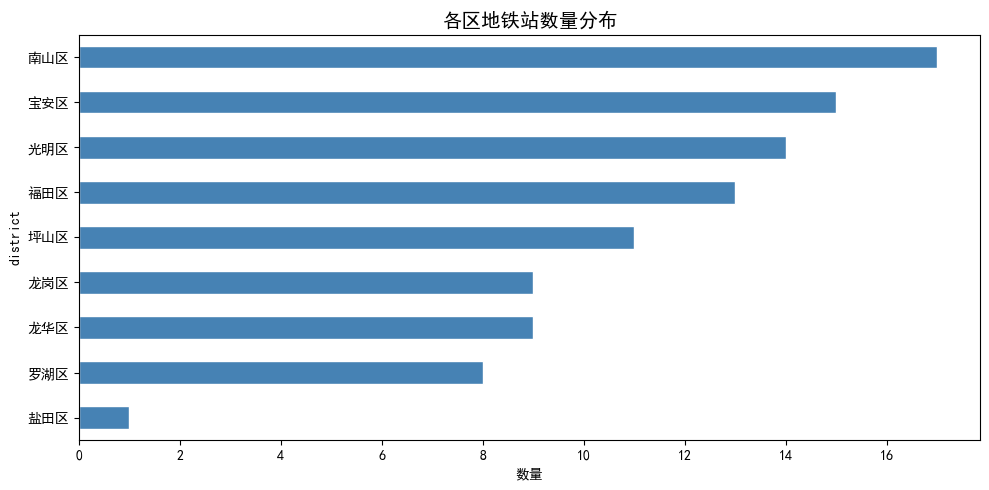

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("output/metro_stations.geojson")
plt.rcParams['font.sans-serif'] = ['SimHei']

print("===== 数据质量检查报告 =====")
print(f"总记录数: {len(gdf)}")
print("\n缺失值统计:\n", gdf.isnull().sum())
dup = gdf.duplicated(subset=['name', 'longitude', 'latitude']).sum()
print(f"\n重复记录数: {dup}")
print(f"\n经度范围: {gdf['longitude'].min():.4f} ~ {gdf['longitude'].max():.4f}")
print(f"纬度范围: {gdf['latitude'].min():.4f} ~ {gdf['latitude'].max():.4f}")

# 各区记录数柱状图
fig, ax = plt.subplots(figsize=(10, 5))
gdf.groupby('district').size().sort_values(ascending=True).plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('各区地铁站数量分布', fontsize=14)
ax.set_xlabel('数量')
plt.tight_layout()
plt.savefig('output/metro_by_district.png', dpi=150, bbox_inches='tight')
plt.show()